# Phase 2 — Bounded Envelope Residual Correction

Continuing from `neural_buchdahl.ipynb` (Part 1), where we established:

- **Anchor-preserving repair** (variant C) fixes physical consistency
  and improves downstream apo-doublet agreement with Sellmeier truth
  (Claim G: median $|\Delta S|$ 12 μm → 1.5 μm).
- **Neural ν3, ν4 (variant D)** adds nothing over linear C at $N = 544$
  glasses with 3-d input.
- The **residual ~1.5 μm** is consistent with the **Oracle** upper bound
  — i.e. the **4-term anchor-preserving Buchdahl floor** at the
  Level-1 spectral-fit target.

Phase 2 asks whether the residual floor can be pushed lower by **adding
a neural correction that lives inside the same anchor constraints**.

## Architecture

$$n_\text{total}(\lambda) = n_C(\lambda) + \varepsilon_\text{scale}
 \cdot q_\text{norm}(x) \cdot \tanh\bigl(\text{NN}(\tilde n_d,
 \tilde V_d, \widetilde{\Delta P_{g,F}}, x)\bigr)$$

with:

- $x(\lambda) \in [-1, 1]$ normalized wavelength (training support
  $[0.365, 2.3]$ μm)
- $q(x) = \prod_i (x - x_i)$ with $x_i$ the normalized positions of
  $\lambda_d, \lambda_F, \lambda_C, \lambda_g$
- $q_\text{norm} = q / \max_{x \in \text{train grid}} |q|$, so
  $|q_\text{norm}| \leq 1$
- $\tanh$ bounds the NN output
- $\varepsilon_\text{scale}$: physically interpretable residual-amplitude cap
- NN inputs z-scored

**Key property (by construction)**: $q(x_{d,F,C,g}) = 0 \Rightarrow
\varepsilon(\lambda_{d,F,C,g}) = 0 \Rightarrow
n_\text{total}(\lambda_\text{anchor}) = n_C(\lambda_\text{anchor})$.
Therefore Claims F, G, and the (nd, Vd, dPgF) definitions are
**architecturally invariant** to Phase 2. Phase 2 can only modify
$n(\lambda)$ in the off-anchor spectrum.

## What Phase 2 can and cannot change

| Metric | Phase 2 effect |
|---|---|
| Claim A (17-pt grid RMS) | ↓ expected (training target) |
| H2 (visible dense 200-pt RMS) | ↓ expected |
| H3 (full-support dense 500-pt RMS) | ↓ expected; headline Phase 2 metric |
| Claim E (smoothness) | depends on $\varepsilon_\text{scale}$ |
| Claim F (anchor preservation) | **unchanged** (machine precision by construction) |
| Claim G (secondary spectrum at g/d) | **unchanged** (architectural: residual = 0 at g/d) |

## The central question, operationalized

> Does increasing $\varepsilon_\text{scale}$ (i.e. allowing more
> residual capacity) actually reduce H3? And if so, where does it stop?

Four phenotype regions we'll check against:

| Phenotype | H3_test | H3_gap | E ratios | Residual usage |
|---|---|---|---|---|
| **Effective** | ↓ | small | ≤ 2× | partial |
| **Overfit** | plateau/↑ | large | ↑↑ | saturated |
| **Input bottleneck** | plateau early | small | ≤ 2× | **unsaturated** |
| **Underspecified** | plateau | small | ≤ 2× | **saturated at small ε** |

"Input bottleneck" here means: two glasses with nearly identical
$(n_d, V_d, \Delta P_{g,F})$ can have Sellmeier curves that differ at
non-anchor wavelengths, and no NN with those three scalars as input
can tell them apart.


## Setup


In [1]:
from __future__ import annotations
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

from pathlib import Path
import importlib.util
import re
import time

import numpy as np
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from scipy.optimize import fsolve

np.random.seed(0)
torch.manual_seed(0)
print(f"numpy {np.__version__}, torch {torch.__version__}, pandas {pd.__version__}")


numpy 2.4.3, torch 2.11.0+cpu, pandas 3.0.2


In [2]:
# Buchdahl constants — identical to the other notebooks.
LAMBDA_D = 0.5875618
LAMBDA_g = 0.4358343
LAMBDA_F = 0.4861327
LAMBDA_C = 0.6562725
ALPHA    = 1.818


def buchdahl_omega(lam, alpha=ALPHA):
    dl = lam - LAMBDA_D
    return dl / (1.0 + alpha * dl)


OMEGA_g = buchdahl_omega(LAMBDA_g)
OMEGA_F = buchdahl_omega(LAMBDA_F)
OMEGA_C = buchdahl_omega(LAMBDA_C)

# Training support
LAM_LO, LAM_HI = 0.365, 2.3
ANCHORS = np.array([LAMBDA_D, LAMBDA_F, LAMBDA_C, LAMBDA_g])

# Pool of 2048 wavelengths for random training sampling
LAM_POOL = np.linspace(LAM_LO, LAM_HI, 2048)

# Fixed evaluation grids
LAM_H1 = np.array([
    0.36501, 0.40466, 0.43583, 0.48613, 0.54607,
    0.58756, 0.58929, 0.6328,  0.64385, 0.65627,
    0.70652, 0.85211, 1.01398, 1.060,   1.52958,
    1.97009, 2.3
])
LAM_H2 = np.linspace(0.400, 0.700, 200)
LAM_H3 = np.linspace(LAM_LO, LAM_HI, 500)

# Optiland glass DB
if "OPTILAND_DB_ROOT" in os.environ:
    DB_ROOT = Path(os.environ["OPTILAND_DB_ROOT"])
else:
    _spec = importlib.util.find_spec("optiland")
    if _spec is None or _spec.origin is None:
        raise RuntimeError("optiland not installed")
    DB_ROOT = Path(_spec.origin).parent / "database"
GLASS_ROOT = DB_ROOT / "data-nk" / "glass"
print(f"Glass DB: {GLASS_ROOT}")


Glass DB: C:\Masterthesis\DipersionLab\.venv\Lib\site-packages\optiland\database\data-nk\glass


In [3]:
# ---- Glass loader + cache Sellmeier at all evaluation wavelengths ----
def _sellmeier(lam, sm):
    B1, C1, B2, C2, B3, C3 = sm
    wl2 = lam ** 2
    return np.sqrt(1 + B1*wl2/(wl2-C1) + B2*wl2/(wl2-C2) + B3*wl2/(wl2-C3))


def extract_record(yml_path):
    with yml_path.open("r", encoding="utf-8") as f:
        doc = yaml.safe_load(f)
    data_blocks = doc.get("DATA", [])
    if not data_blocks:
        return None
    formula = data_blocks[0]
    if formula.get("type") != "formula 2":
        return None
    coeffs = formula.get("coefficients", "").split()
    if len(coeffs) != 7:
        return None
    wr = formula.get("wavelength_range", "").split()
    if len(wr) != 2:
        return None
    B1, C1 = float(coeffs[1]), float(coeffs[2])
    B2, C2 = float(coeffs[3]), float(coeffs[4])
    B3, C3 = float(coeffs[5]), float(coeffs[6])
    lam_lo, lam_hi = float(wr[0]), float(wr[1])
    if lam_lo > LAM_LO + 1e-6 or lam_hi < LAM_HI - 1e-6:
        return None
    sm = (B1, C1, B2, C2, B3, C3)
    nd = float(_sellmeier(LAMBDA_D, sm))
    nF = float(_sellmeier(LAMBDA_F, sm))
    nC = float(_sellmeier(LAMBDA_C, sm))
    ng = float(_sellmeier(LAMBDA_g, sm))
    dn_FC = nF - nC
    if dn_FC < 1e-12:
        return None
    vd   = (nd - 1.0) / dn_FC
    PgF  = (ng - nF) / dn_FC
    dPgF = PgF - (0.6438 - 0.001682 * vd)
    return dict(
        name=yml_path.stem, catalog=yml_path.parent.name,
        nd=nd, vd=vd, PgF=PgF, dPgF=dPgF, sellmeier=sm,
        n_H1   = np.array([_sellmeier(lam, sm) for lam in LAM_H1]),
        n_H2   = np.array([_sellmeier(lam, sm) for lam in LAM_H2]),
        n_H3   = np.array([_sellmeier(lam, sm) for lam in LAM_H3]),
        n_pool = np.array([_sellmeier(lam, sm) for lam in LAM_POOL]),
    )


glasses = []
for yml in GLASS_ROOT.rglob("*.yml"):
    rec = extract_record(yml)
    if rec is not None:
        glasses.append(rec)
glasses = [g for g in glasses if 10 < g["vd"] < 100 and -0.02 < g["dPgF"] < 0.10]
N_GLASS = len(glasses)
print(f"Loaded {N_GLASS} glasses with Sellmeier + pre-computed H1/H2/H3/pool grids.")


Loaded 544 glasses with Sellmeier + pre-computed H1/H2/H3/pool grids.


## Reconstruct Phase 1 baseline (anchor linear, variant C)

We recompute Phase 1's anchor-preserving linear $A_\text{REG}'$ inline
rather than loading a saved file — this keeps the notebook
self-contained and independent of the Phase 1 notebook's seed choices.
Cluster split is identical (same DBSCAN eps=0.15, same seed=0).


In [4]:
# Anchor-preserving Level 1 fit (same as Phase 1 Part 1A)
M_MAT = np.array([
    [OMEGA_F - OMEGA_C,   OMEGA_F**2 - OMEGA_C**2],
    [OMEGA_g - OMEGA_F,   OMEGA_g**2 - OMEGA_F**2],
])
D_MAT = np.array([
    [OMEGA_F**3 - OMEGA_C**3,  OMEGA_F**4 - OMEGA_C**4],
    [OMEGA_g**3 - OMEGA_F**3,  OMEGA_g**4 - OMEGA_F**4],
])
M_INV = np.linalg.inv(M_MAT)
B_COUP = M_INV @ D_MAT


def anchor_preserving_fit(nd, vd, dPgF, n_truth, omega_grid):
    dn_FC = (nd - 1.0) / vd
    PgF = 0.6438 - 0.001682*vd + dPgF
    dn_gF = PgF * dn_FC
    a = M_INV @ np.array([dn_FC, dn_gF])
    phi3 = omega_grid**3 - omega_grid*B_COUP[0,0] - omega_grid**2 * B_COUP[1,0]
    phi4 = omega_grid**4 - omega_grid*B_COUP[0,1] - omega_grid**2 * B_COUP[1,1]
    basis = np.column_stack([phi3, phi4])
    target = n_truth - nd - omega_grid*a[0] - omega_grid**2 * a[1]
    nu34, *_ = np.linalg.lstsq(basis, target, rcond=None)
    nu12 = a - B_COUP @ nu34
    return nu12[0], nu12[1], nu34[0], nu34[1]


# Per-glass anchor targets (using 17-pt H1 grid, same as Phase 1 training)
OMEGA_H1 = buchdahl_omega(LAM_H1)
new_coefs = np.zeros((N_GLASS, 4))
for i, g in enumerate(glasses):
    new_coefs[i] = anchor_preserving_fit(g["nd"], g["vd"], g["dPgF"],
                                         g["n_H1"], OMEGA_H1)

# 20-dim polynomial features
def feature_vec(nd, vd, dPgF):
    sq = [1.0, nd, vd, dPgF, nd*nd, vd*vd, dPgF*dPgF, nd*vd, nd*dPgF, vd*dPgF]
    cu = [nd**3, vd**3, dPgF**3, nd*nd*vd, nd*nd*dPgF, vd*vd*nd, vd*vd*dPgF,
          dPgF*dPgF*nd, dPgF*dPgF*vd, nd*vd*dPgF]
    return np.array(sq + cu, dtype=np.float64)

Phi = np.array([feature_vec(g["nd"], g["vd"], g["dPgF"]) for g in glasses])

# Cluster split identical to Phase 1
X_params = np.array([[g["nd"], g["vd"], g["dPgF"]] for g in glasses])
X_scaled = StandardScaler().fit_transform(X_params)
db = DBSCAN(eps=0.15, min_samples=2).fit(X_scaled)
cluster_ids = db.labels_.copy()
next_id = cluster_ids.max() + 1
for i, cid in enumerate(cluster_ids):
    if cid == -1:
        cluster_ids[i] = next_id
        next_id += 1
unique_clusters = np.unique(cluster_ids)
rng = np.random.default_rng(0)
perm = rng.permutation(unique_clusters)
n_train = int(0.8 * len(perm))
train_clusters = set(perm[:n_train])
train_mask = np.array([cid in train_clusters for cid in cluster_ids])
test_mask  = ~train_mask

# Train A_REG_anchor (variant C) — same as Phase 1
Y_anchor = new_coefs[:, 2:]
A_REG_anchor, *_ = np.linalg.lstsq(Phi[train_mask], Y_anchor[train_mask], rcond=None)


def predict_C_coefs(i_glass):
    """Return (nu1, nu2, nu3, nu4) for glass i under variant C."""
    nu34 = Phi[i_glass] @ A_REG_anchor
    g = glasses[i_glass]
    dn_FC = (g["nd"] - 1.0) / g["vd"]
    PgF = 0.6438 - 0.001682*g["vd"] + g["dPgF"]
    dn_gF = PgF * dn_FC
    a = M_INV @ np.array([dn_FC, dn_gF])
    nu12 = a - B_COUP @ nu34
    return np.array([nu12[0], nu12[1], nu34[0], nu34[1]])


def n_base(i_glass, lam_grid):
    """Variant C baseline n(lambda) on a given grid."""
    nu14 = predict_C_coefs(i_glass)
    om = buchdahl_omega(lam_grid)
    n = glasses[i_glass]["nd"] * np.ones_like(om)
    for k, nk in enumerate(nu14, 1):
        n = n + nk * om**k
    return n


# Cache C baseline for each glass on each eval grid (large memory but fast inner loop)
t0 = time.time()
n_C_pool = np.array([n_base(i, LAM_POOL) for i in range(N_GLASS)])
n_C_H1   = np.array([n_base(i, LAM_H1)   for i in range(N_GLASS)])
n_C_H2   = np.array([n_base(i, LAM_H2)   for i in range(N_GLASS)])
n_C_H3   = np.array([n_base(i, LAM_H3)   for i in range(N_GLASS)])
n_C_anc  = np.array([n_base(i, ANCHORS)  for i in range(N_GLASS)])
print(f"Phase 1 C baseline cached on H1/H2/H3/pool/anchors in {time.time()-t0:.1f} s")
print(f"  shapes: pool {n_C_pool.shape}, H1 {n_C_H1.shape}, "
      f"H2 {n_C_H2.shape}, H3 {n_C_H3.shape}")

# Also the D baseline (anchor MLP, reference only)
Y_anchor_train = Y_anchor[train_mask]
X_raw = X_params
x_mean = X_raw[train_mask].mean(axis=0)
x_std  = X_raw[train_mask].std(axis=0) + 1e-9
X_norm = (X_raw - x_mean) / x_std
y_mean = Y_anchor_train.mean(axis=0)
y_std  = Y_anchor_train.std(axis=0) + 1e-9
Y_norm_anchor = (Y_anchor - y_mean) / y_std


class TanhMLP(torch.nn.Module):
    def __init__(self, d_in=3, d_hidden=16, d_out=2):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(d_in, d_hidden), torch.nn.Tanh(),
            torch.nn.Linear(d_hidden, d_hidden), torch.nn.Tanh(),
            torch.nn.Linear(d_hidden, d_out),
        )
    def forward(self, x):
        return self.net(x)


def train_D_mlp(seed):
    torch.manual_seed(seed)
    m = TanhMLP().double()
    Xt = torch.tensor(X_norm[train_mask], dtype=torch.float64)
    Yt = torch.tensor(Y_norm_anchor[train_mask], dtype=torch.float64)
    opt = torch.optim.Adam(m.parameters(), lr=3e-3, weight_decay=1e-3)
    for _ in range(3000):
        opt.zero_grad()
        loss = torch.nn.functional.mse_loss(m(Xt), Yt)
        loss.backward()
        opt.step()
    return m


D_models = [train_D_mlp(s) for s in range(5)]
with torch.no_grad():
    X_all = torch.tensor(X_norm, dtype=torch.float64)
    D_pred_norm = torch.stack([m(X_all) for m in D_models], dim=0).mean(dim=0).numpy()
Y_D = D_pred_norm * y_std + y_mean


def predict_D_coefs(i_glass):
    nu34 = Y_D[i_glass]
    g = glasses[i_glass]
    dn_FC = (g["nd"] - 1.0) / g["vd"]
    PgF = 0.6438 - 0.001682*g["vd"] + g["dPgF"]
    dn_gF = PgF * dn_FC
    a = M_INV @ np.array([dn_FC, dn_gF])
    nu12 = a - B_COUP @ nu34
    return np.array([nu12[0], nu12[1], nu34[0], nu34[1]])


def n_D_on_grid(i_glass, lam_grid):
    nu14 = predict_D_coefs(i_glass)
    om = buchdahl_omega(lam_grid)
    n = glasses[i_glass]["nd"] * np.ones_like(om)
    for k, nk in enumerate(nu14, 1):
        n = n + nk * om**k
    return n

n_D_H1 = np.array([n_D_on_grid(i, LAM_H1) for i in range(N_GLASS)])
n_D_H2 = np.array([n_D_on_grid(i, LAM_H2) for i in range(N_GLASS)])
n_D_H3 = np.array([n_D_on_grid(i, LAM_H3) for i in range(N_GLASS)])

print(f"Phase 1 D (MLP) baseline cached.")


Phase 1 C baseline cached on H1/H2/H3/pool/anchors in 0.1 s
  shapes: pool (544, 2048), H1 (544, 17), H2 (544, 200), H3 (544, 500)


Phase 1 D (MLP) baseline cached.


## Envelope $q_\text{norm}(x)$

Normalize wavelength to $x \in [-1, 1]$ over $[\lambda_\text{lo},
\lambda_\text{hi}] = [0.365, 2.3]$ μm. Place anchor nodes at the
four spectral lines. The raw envelope is the 4-root polynomial; we
normalize by its max magnitude on the training pool so
$|q_\text{norm}| \leq 1$ there.


Q_SCALE = 10.8625
max |q_norm| on training pool: 1.0000
max |q_norm(x_anchor)|:        0.000e+00   (must be ~1e-15)


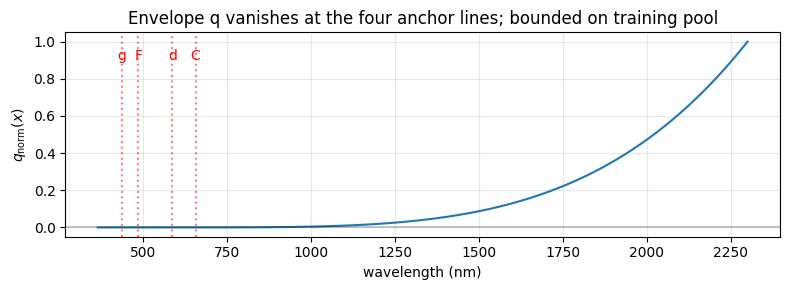

In [5]:
def normalize_lam(lam):
    return 2.0 * (lam - LAM_LO) / (LAM_HI - LAM_LO) - 1.0


X_ANCHORS = normalize_lam(ANCHORS)  # normalized positions of d, F, C, g


def q_raw(x):
    # product of (x - x_anchor_i) for i = d, F, C, g
    result = np.ones_like(x) if hasattr(x, "shape") else 1.0
    for xi in X_ANCHORS:
        result = result * (x - xi)
    return result


# Normalize so |q_norm| <= 1 on training pool
X_POOL = normalize_lam(LAM_POOL)
Q_SCALE = float(np.max(np.abs(q_raw(X_POOL))))


def q_norm(x):
    return q_raw(x) / Q_SCALE


# Sanity: must vanish at anchors to ~1e-15
max_anchor_q = float(np.max(np.abs(q_norm(X_ANCHORS))))
print(f"Q_SCALE = {Q_SCALE:.4f}")
print(f"max |q_norm| on training pool: {np.abs(q_norm(X_POOL)).max():.4f}")
print(f"max |q_norm(x_anchor)|:        {max_anchor_q:.3e}   "
      f"(must be ~1e-15)")
assert max_anchor_q < 1e-12, "anchor constraint violated"

# Quick plot
fig, ax = plt.subplots(figsize=(8, 3))
x_plot = normalize_lam(np.linspace(LAM_LO, LAM_HI, 500))
lam_plot = np.linspace(LAM_LO, LAM_HI, 500)
ax.plot(lam_plot * 1000, q_norm(x_plot))
for lam, name in zip(ANCHORS, ['d', 'F', 'C', 'g']):
    ax.axvline(lam * 1000, color='r', ls=':', alpha=0.5)
    ax.annotate(name, (lam * 1000, 0.9), color='r', ha='center')
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel("wavelength (nm)")
ax.set_ylabel(r"$q_\mathrm{norm}(x)$")
ax.set_title("Envelope q vanishes at the four anchor lines; bounded on training pool")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Phase 2 Neural architecture

Small MLP $(4) \to (32) \to (32) \to (1)$ with tanh activations.
Inputs: $(\tilde n_d, \tilde V_d, \widetilde{\Delta P_{g,F}},
x)$ z-scored. Output is one scalar in $[-1, 1]$ via final tanh;
multiplied by $q_\text{norm}(x) \cdot \varepsilon_\text{scale}$ to
get the residual $\varepsilon(\lambda; n_d, V_d, \Delta P_{g,F})$.

Training:

- Loss: $\text{MSE}\bigl(n_\text{total} - n_\text{Sellmeier}\bigr)$ over random
  batches of (glass, wavelength).
- Per-epoch sampling: for each glass in the training split, sample
  $K = 64$ wavelengths from the 2048-point pool. This is "dense"
  training on the full support $[0.365, 2.3]$, not just 17 points.
- 5-seed ensemble per $\varepsilon_\text{scale}$.
- $\varepsilon_\text{scale}$ sweep, split into **main physical range**
  $\{10^{-3}, 3 \times 10^{-3}, 10^{-2}\}$ (where the cap is a
  genuinely small residual correction) and a **stress range**
  $\{3 \times 10^{-2}, 10^{-1}\}$ (where the cap is large enough to
  absorb a substantial fraction of $n(\lambda)$ itself; useful for
  probing overfit behaviour but not a proposed operating point).


In [6]:
# Normalize the 3-param inputs over the TRAIN subset
p_mean = X_params[train_mask].mean(axis=0)
p_std  = X_params[train_mask].std(axis=0) + 1e-9
P_norm = (X_params - p_mean) / p_std                        # (N, 3)

# Pre-tensorize everything we need during training
P_norm_t = torch.tensor(P_norm, dtype=torch.float64)           # (N, 3)
X_pool_t = torch.tensor(X_POOL, dtype=torch.float64)           # (L,) normalized lambdas
q_pool_t = torch.tensor(q_norm(X_POOL), dtype=torch.float64)   # (L,) q on pool
n_C_pool_t = torch.tensor(n_C_pool, dtype=torch.float64)       # (N, L)
n_sellmeier_pool_t = torch.tensor(
    np.array([g["n_pool"] for g in glasses]), dtype=torch.float64
)                                                               # (N, L)

# Residual "oracle" on the training pool — what the ideal NN would output
residual_oracle_pool = (n_sellmeier_pool_t - n_C_pool_t)       # (N, L)
print(f"Oracle residual on training pool:")
print(f"  max |n_truth - n_C|: {residual_oracle_pool.abs().max().item():.3e}")
print(f"  RMS:                 {residual_oracle_pool.pow(2).mean().sqrt().item():.3e}")

train_idx = np.where(train_mask)[0]
test_idx  = np.where(test_mask)[0]
print(f"Train: {len(train_idx)} glasses, Test: {len(test_idx)} glasses")


Oracle residual on training pool:
  max |n_truth - n_C|: 6.632e-03
  RMS:                 1.291e-03
Train: 461 glasses, Test: 83 glasses


In [7]:
class Phase2NN(torch.nn.Module):
    def __init__(self, d_hidden=32):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(4, d_hidden), torch.nn.Tanh(),
            torch.nn.Linear(d_hidden, d_hidden), torch.nn.Tanh(),
            torch.nn.Linear(d_hidden, 1),
            torch.nn.Tanh(),      # bounded output in [-1, 1]
        )
    def forward(self, x4):
        return self.net(x4).squeeze(-1)


def train_phase2(eps_scale, seed, epochs=2000, K=64, lr=1e-2, weight_decay=0.0):
    """Train one seed. Returns (model, train_loss_history)."""
    torch.manual_seed(seed)
    model = Phase2NN().double()
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    N_train = len(train_idx)
    L_pool  = len(X_pool_t)
    loss_hist = []
    for ep in range(epochs):
        # Sample K wavelengths per glass per epoch, independently
        lam_idx = torch.randint(0, L_pool, (N_train, K))        # (N_train, K)
        x_l  = X_pool_t[lam_idx]                                  # (N_train, K)
        q_l  = q_pool_t[lam_idx]                                  # (N_train, K)
        p_tr = P_norm_t[train_idx].unsqueeze(1).expand(-1, K, -1)  # (N_train, K, 3)

        inp = torch.cat([p_tr, x_l.unsqueeze(-1)], dim=-1)        # (N_train, K, 4)
        tanh_out = model(inp.reshape(-1, 4)).reshape(N_train, K)   # (N_train, K)
        eps = eps_scale * q_l * tanh_out                           # (N_train, K)

        n_base_l = n_C_pool_t[train_idx].gather(1, lam_idx)       # (N_train, K)
        n_true_l = n_sellmeier_pool_t[train_idx].gather(1, lam_idx)
        n_pred   = n_base_l + eps

        loss = torch.nn.functional.mse_loss(n_pred, n_true_l)
        opt.zero_grad(); loss.backward(); opt.step()
        loss_hist.append(loss.item())
    return model, loss_hist


def infer_phase2(model, eps_scale, lam_grid_norm, q_grid, i_glasses):
    """Return residual epsilon (i_glasses, len(lam_grid_norm))."""
    N = len(i_glasses)
    L = len(lam_grid_norm)
    x_l  = torch.tensor(lam_grid_norm, dtype=torch.float64)
    q_l  = torch.tensor(q_grid, dtype=torch.float64)
    p_t  = P_norm_t[i_glasses]
    inp = torch.cat([p_t.unsqueeze(1).expand(-1, L, -1),
                     x_l.view(1, L, 1).expand(N, L, 1)], dim=-1)
    with torch.no_grad():
        tanh_out = model(inp.reshape(-1, 4)).reshape(N, L)
        eps = eps_scale * q_l.view(1, L) * tanh_out
    return eps.numpy(), tanh_out.abs().max().item()


def ensemble_eps(models, eps_scale, lam_grid, i_glasses):
    x_norm = normalize_lam(lam_grid)
    q_g    = q_norm(x_norm)
    N = len(i_glasses); L = len(lam_grid)
    eps_sum = np.zeros((N, L))
    max_use = 0.0
    for m in models:
        e, mu = infer_phase2(m, eps_scale, x_norm, q_g, i_glasses)
        eps_sum += e
        if mu > max_use: max_use = mu
    return eps_sum / len(models), max_use


In [8]:
# --- Run the eps_scale sweep ---
EPS_SWEEP = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
N_SEEDS   = 5
EPOCHS    = 2000

all_models = {}
t0 = time.time()
for eps in EPS_SWEEP:
    t_eps = time.time()
    models = [train_phase2(eps, seed=s, epochs=EPOCHS, lr=1e-2, weight_decay=0.0)[0] for s in range(N_SEEDS)]
    all_models[eps] = models
    print(f"eps={eps:.0e}: {N_SEEDS} seeds trained in {time.time()-t_eps:.1f} s")
print(f"Total training time: {time.time()-t0:.1f} s")


eps=1e-03: 5 seeds trained in 113.1 s


eps=3e-03: 5 seeds trained in 112.5 s


eps=1e-02: 5 seeds trained in 148.7 s


eps=3e-02: 5 seeds trained in 125.2 s


eps=1e-01: 5 seeds trained in 115.3 s
Total training time: 614.8 s


In [9]:
# ---- Evaluation helpers ----

i_all   = np.arange(N_GLASS)
i_train = train_idx
i_test  = test_idx


def phase2_eval(models, eps):
    """For each evaluation grid, compute errors and residual-usage."""
    out = {}
    for name, lam, nC_cache, n_truth_cache in [
        ("H1", LAM_H1, n_C_H1, np.array([g["n_H1"] for g in glasses])),
        ("H2", LAM_H2, n_C_H2, np.array([g["n_H2"] for g in glasses])),
        ("H3", LAM_H3, n_C_H3, np.array([g["n_H3"] for g in glasses])),
    ]:
        eps_grid, max_use = ensemble_eps(models, eps, lam, i_all)
        n_total = nC_cache + eps_grid
        err = np.abs(n_total - n_truth_cache)
        out[name] = dict(
            err_train = err[i_train],
            err_test  = err[i_test],
            err_all   = err,
            max_use   = max_use,
        )
    # Also anchor invariance check
    eps_anc, _ = ensemble_eps(models, eps, ANCHORS, i_all)
    out["anchor_delta_max"] = float(np.abs(eps_anc).max())
    return out


# Also evaluate the C and D baselines (for comparison rows)
def baseline_eval(nC_cache_by_grid, name):
    out = {}
    for gname, lam, nC_cache, n_truth_cache in [
        ("H1", LAM_H1, nC_cache_by_grid["H1"], np.array([g["n_H1"] for g in glasses])),
        ("H2", LAM_H2, nC_cache_by_grid["H2"], np.array([g["n_H2"] for g in glasses])),
        ("H3", LAM_H3, nC_cache_by_grid["H3"], np.array([g["n_H3"] for g in glasses])),
    ]:
        err = np.abs(nC_cache - n_truth_cache)
        out[gname] = dict(
            err_train=err[i_train], err_test=err[i_test], err_all=err,
            max_use=0.0,
        )
    out["anchor_delta_max"] = 0.0
    return out


C_baseline = baseline_eval(dict(H1=n_C_H1, H2=n_C_H2, H3=n_C_H3), "C")
D_baseline = baseline_eval(dict(H1=n_D_H1, H2=n_D_H2, H3=n_D_H3), "D")
phase2_results = {eps: phase2_eval(all_models[eps], eps) for eps in EPS_SWEEP}

print("All variants evaluated on H1/H2/H3 grids.")


All variants evaluated on H1/H2/H3 grids.


## Claim E — smoothness in $(n_d, V_d)$ parameter space

**Metric design note**: we measure smoothness of

$$\text{field}(n_d, V_d) = \text{RMS}_{\lambda \in [0.365, 2.3]}\,
\big|n_\text{total}(\lambda) - n_C(\lambda)\big|$$

on a $21 \times 21$ $(n_d, V_d)$ grid around the D-FK95-25 reference.
Key choices:

- We use the **Phase 2 residual** (not $n_\text{total}$ itself) so that
  the baseline $C$ is identically 0 — the field directly measures the
  NN's contribution.
- The band is the **full training support** 0.365–2.3 μm. Visible-only
  bands (0.4–0.7 μm) sit between the four anchor roots of
  $q_\text{norm}$ and would give a near-zero field that doesn't reflect
  actual NN behavior. Full band exposes the IR region where
  $q_\text{norm}$ is large and the residual actually lives.

Reports: `E_field` (max of the field), `E_grad` (max finite-difference
gradient), `E_curv` (max curvature), and `rel_curv = E_curv / E_field`
— the dimensionless wiggliness indicator. Large `rel_curv` means the
NN produces sharp features in parameter space; small `rel_curv` means
the residual varies smoothly with $(n_d, V_d)$.


In [10]:
# Find reference glass D-FK95-25 (or fallback)
ref_name = "D-FK95-25"
ref_idx = next((i for i, g in enumerate(glasses) if g["name"] == ref_name), None)
if ref_idx is None:
    # fallback: any FK
    ref_idx = next(i for i, g in enumerate(glasses) if "FK" in g["name"].upper())
    ref_name = glasses[ref_idx]["name"]
ref = glasses[ref_idx]
print(f"Reference glass for Claim E: {ref_name}  "
      f"(nd={ref['nd']:.4f}, Vd={ref['vd']:.2f}, dPgF={ref['dPgF']:+.4f})")

# 21x21 grid of perturbations (small — stay inside the training box)
dnd_grid = np.linspace(-0.003, 0.003, 21)
dvd_grid = np.linspace(-1.5,   1.5,   21)

# Fast evaluator of full n(lambda) on H3 grid for arbitrary (nd, Vd, dPgF)
# using an anchor-preserving linear predictor + optional Phase 2 residual.
def n_for_params(nd, vd, dPgF, lam_grid, phase2_models=None, phase2_eps=0.0):
    # Level 2 linear predictor C for ν3, ν4 (same A_REG_anchor)
    nu34 = feature_vec(nd, vd, dPgF) @ A_REG_anchor
    # Anchor-preserving ν1, ν2
    dn_FC = (nd - 1.0) / vd
    PgF = 0.6438 - 0.001682*vd + dPgF
    dn_gF = PgF * dn_FC
    a = M_INV @ np.array([dn_FC, dn_gF])
    nu12 = a - B_COUP @ nu34
    om = buchdahl_omega(lam_grid)
    nu14 = [nu12[0], nu12[1], nu34[0], nu34[1]]
    n = nd * np.ones_like(om)
    for k, nk in enumerate(nu14, 1):
        n = n + nk * om**k
    if phase2_models is not None and phase2_eps > 0:
        x_norm = normalize_lam(lam_grid)
        q_g = q_norm(x_norm)
        # z-score the 3-param input the same way training did
        p = (np.array([nd, vd, dPgF]) - p_mean) / p_std
        eps_sum = np.zeros_like(lam_grid)
        max_use = 0.0
        for m in phase2_models:
            with torch.no_grad():
                x_in = torch.tensor(
                    np.column_stack([np.tile(p, (len(lam_grid), 1)), x_norm]),
                    dtype=torch.float64,
                )
                t_out = m(x_in).numpy()
                max_use = max(max_use, float(np.abs(t_out).max()))
                eps_sum += phase2_eps * q_g * t_out
        n = n + eps_sum / len(phase2_models)
    return n


LAM_SMOOTH = np.linspace(0.365, 2.3, 100)   # full training support — q_norm has
                                             # non-trivial magnitude here (unlike
                                             # a visible-only band, which sits in
                                             # q's dead zone between d/F/C/g roots)


def residual_field_grid(phase2_models, phase2_eps, lam_band=LAM_SMOOTH):
    """RMS (over lam_band) of the Phase 2 residual  n_total - n_C  as a
    function of (nd, Vd) on a 21x21 grid around the reference glass.

    Measuring the *residual* (not n_total) is what actually probes NN
    smoothness in parameter space — baseline C's large nd-dependence
    would otherwise dominate any field based on n_model itself and mask
    the NN's contribution.
    """
    field = np.full((len(dnd_grid), len(dvd_grid)), np.nan)
    for i, dnd in enumerate(dnd_grid):
        for j, dvd in enumerate(dvd_grid):
            nd = ref["nd"] + dnd
            vd = ref["vd"] + dvd
            n_C_local     = n_for_params(nd, vd, ref["dPgF"], lam_band)
            n_total_local = n_for_params(nd, vd, ref["dPgF"], lam_band,
                                         phase2_models=phase2_models,
                                         phase2_eps=phase2_eps)
            residual = n_total_local - n_C_local
            field[i, j] = float(np.sqrt(np.mean(residual ** 2)))
    return field


def smoothness_metrics(grid):
    """Max |finite-difference gradient| and max |second-difference curvature|."""
    gx = np.diff(grid, axis=0)
    gy = np.diff(grid, axis=1)
    hx = np.diff(grid, n=2, axis=0)
    hy = np.diff(grid, n=2, axis=1)
    return float(max(np.abs(gx).max(), np.abs(gy).max())), \
           float(max(np.abs(hx).max(), np.abs(hy).max()))


# Baseline C: residual = 0 by definition, so field = 0, grad = curv = 0.
# We report this row as 0 for reference; the Phase 2 rows carry the signal.
print(f"Baseline C: residual field identically 0 (architectural)")
print(f"  -> grad_max = 0, curv_max = 0")
print()

E_abs_table = {}
for eps in EPS_SWEEP:
    S_g = residual_field_grid(all_models[eps], eps)
    g_m, c_m = smoothness_metrics(S_g)
    field_max = float(np.abs(S_g).max())
    E_abs_table[eps] = dict(
        field_max=field_max,
        grad_max=g_m,
        curv_max=c_m,
    )
    # Normalized ratios (curv/grad and grad/field_max) are the actual
    # smoothness indicators — they measure how "wiggly" the residual
    # field is relative to its own magnitude.
    rel_grad = g_m / max(field_max, 1e-30)
    rel_curv = c_m / max(field_max, 1e-30)
    print(f"eps={eps:.0e}: field_max={field_max:.3e}, "
          f"grad_max={g_m:.3e}, curv_max={c_m:.3e}  "
          f"(rel_grad={rel_grad:.3f}, rel_curv={rel_curv:.3f})")
print()
print("rel_grad, rel_curv: gradient/curvature relative to the residual field's")
print("max magnitude itself. Smaller = smoother NN. If residual is smooth and")
print("slowly-varying in (nd, Vd), these stay moderate (< 1 or so).")


Reference glass for Claim E: D-FK95-25  (nd=1.4374, Vd=94.44, dPgF=+0.0485)
Baseline C: residual field identically 0 (architectural)
  -> grad_max = 0, curv_max = 0



eps=1e-03: field_max=2.178e-04, grad_max=5.643e-07, curv_max=6.924e-09  (rel_grad=0.003, rel_curv=0.000)


eps=3e-03: field_max=3.005e-04, grad_max=3.731e-07, curv_max=5.281e-09  (rel_grad=0.001, rel_curv=0.000)


eps=1e-02: field_max=4.106e-04, grad_max=3.353e-07, curv_max=1.689e-08  (rel_grad=0.001, rel_curv=0.000)


eps=3e-02: field_max=4.904e-04, grad_max=1.511e-06, curv_max=2.248e-08  (rel_grad=0.003, rel_curv=0.000)


eps=1e-01: field_max=5.180e-04, grad_max=1.340e-06, curv_max=2.275e-08  (rel_grad=0.003, rel_curv=0.000)

rel_grad, rel_curv: gradient/curvature relative to the residual field's
max magnitude itself. Smaller = smoother NN. If residual is smooth and
slowly-varying in (nd, Vd), these stay moderate (< 1 or so).


## Phase 2 scorecard

Rows: baselines (C, D) + each $\varepsilon_\text{scale}$ in the sweep.

Columns follow the design matrix:

- **H1_max / P95 / RMS**: 17-pt grid (Phase 1 Claim A metric)
- **H2_RMS**: 200-pt dense in the visible (0.4–0.7 μm)
- **H3_train_RMS / H3_test_RMS / H3_gap**: full-support 500-pt dense,
  with train/test split + gap (test / train); `H3_gap` is the overfit
  diagnostic
- **G_anchor_delta**: $\max |n_\text{total}(\lambda_\text{anchor}) - n_C(\lambda_\text{anchor})|$ —
  architectural invariance check
- **E_field / E_grad / E_curv**: residual field magnitude, max gradient
  and max curvature in $(n_d, V_d)$ space. For C baseline the residual
  is identically 0 so all three are 0. For Phase 2, these are absolute
  quantities — small `E_grad` / `E_curv` relative to `E_field` = smooth
  NN in parameter space; the `rel_curv` column (curv/field_max) is the
  diagnostic for NN-induced wiggles.
- **resid_use**: max $|\tanh|$ output over the training pool (1.0 = saturated)


In [11]:
def rms(x):
    return float(np.sqrt(np.mean(np.array(x)**2)))


def row_for(name, result, E_abs=None, resid_use=None):
    H1 = result["H1"]
    H2 = result["H2"]
    H3 = result["H3"]
    train_rms = rms(H3["err_train"])
    test_rms  = rms(H3["err_test"])
    if E_abs is None:
        field_max, g, c, rel_c = 0.0, 0.0, 0.0, 0.0
    else:
        field_max = E_abs["field_max"]
        g = E_abs["grad_max"]
        c = E_abs["curv_max"]
        rel_c = c / max(field_max, 1e-30)
    return {
        "H1_max":    float(H1["err_test"].max()) if H1["err_test"].size else float("nan"),
        "H1_P95":    float(np.percentile(H1["err_test"], 95)) if H1["err_test"].size else float("nan"),
        "H1_RMS":    rms(H1["err_test"]),
        "H2_RMS":    rms(H2["err_test"]),
        "H3_train_RMS": train_rms,
        "H3_test_RMS":  test_rms,
        "H3_gap":       (test_rms / train_rms) if train_rms > 0 else float("nan"),
        "G_anchor_delta": float(result.get("anchor_delta_max", 0.0)),
        "E_field":   float(field_max),
        "E_grad":    float(g),
        "E_curv":    float(c),
        "rel_curv":  float(rel_c),
        "resid_use": float(resid_use) if resid_use is not None else 0.0,
    }


rows = {}
rows["C_anchor_linear"] = row_for("C", C_baseline)
rows["D_anchor_mlp"]    = row_for("D", D_baseline)
for eps in EPS_SWEEP:
    label = f"P2_eps={eps:.0e}"
    res = phase2_results[eps]
    ru  = max(res[g]["max_use"] for g in ("H1","H2","H3"))
    rows[label] = row_for(label, res, E_abs=E_abs_table[eps], resid_use=ru)

scorecard = pd.DataFrame(rows).T
pd.set_option("display.float_format", lambda x: f"{x:.3e}" if abs(x) < 1 else f"{x:.4f}")
print(scorecard)


                   H1_max    H1_P95    H1_RMS    H2_RMS  H3_train_RMS  \
C_anchor_linear 6.632e-03 2.323e-03 1.023e-03 5.503e-05     1.270e-03   
D_anchor_mlp    6.588e-03 2.309e-03 1.014e-03 5.500e-05     1.270e-03   
P2_eps=1e-03    5.633e-03 2.185e-03 8.968e-04 5.503e-05     1.147e-03   
P2_eps=3e-03    4.670e-03 2.058e-03 8.089e-04 5.503e-05     1.018e-03   
P2_eps=1e-02    4.414e-03 1.791e-03 7.174e-04 5.501e-05     7.989e-04   
P2_eps=3e-02    4.740e-03 1.715e-03 6.435e-04 5.496e-05     5.730e-04   
P2_eps=1e-01    4.618e-03 1.753e-03 6.118e-04 5.483e-05     4.640e-04   

                 H3_test_RMS  H3_gap  G_anchor_delta   E_field    E_grad  \
C_anchor_linear    1.413e-03  1.1128       0.000e+00 0.000e+00 0.000e+00   
D_anchor_mlp       1.356e-03  1.0678       0.000e+00 0.000e+00 0.000e+00   
P2_eps=1e-03       1.291e-03  1.1251       0.000e+00 2.178e-04 5.643e-07   
P2_eps=3e-03       1.154e-03  1.1327       0.000e+00 3.005e-04 3.731e-07   
P2_eps=1e-02       9.175e-04  1.148

## Diagnostic plots — $\varepsilon_\text{scale}$ ablation

Three views per sweep value:

1. $\varepsilon_\text{scale}$ vs $H3_\text{train}$ and $H3_\text{test}$ RMS
   — overfit detection via train/test gap.
2. $\varepsilon_\text{scale}$ vs $E_\text{grad}$ and $E_\text{curv}$ ratios
   — smoothness degradation (log–log).
3. $\varepsilon_\text{scale}$ vs $\max|\tanh|$ (residual usage) — tells
   us whether the NN is pressed against its bound or is self-limiting.


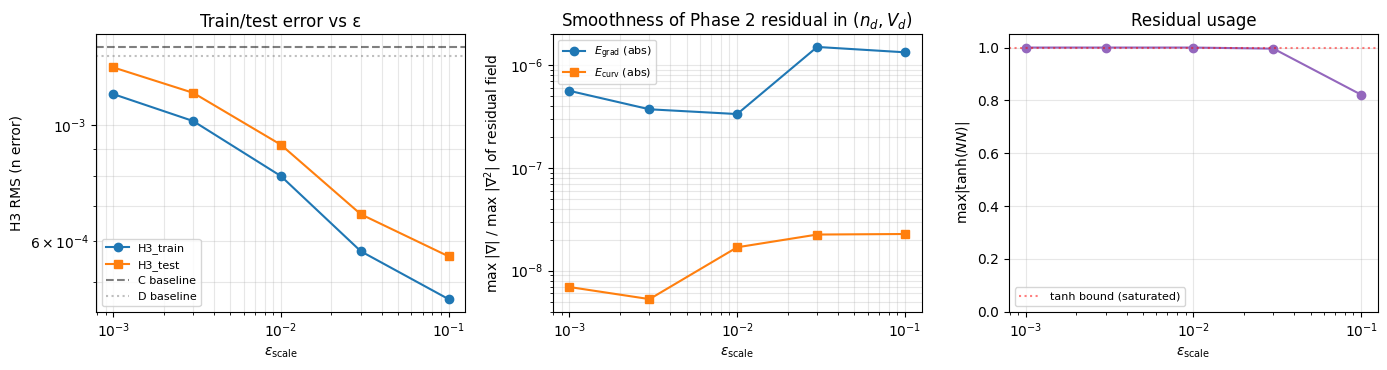

In [12]:
eps_arr = np.array(EPS_SWEEP)
H3_train_arr = np.array([scorecard.loc[f"P2_eps={e:.0e}", "H3_train_RMS"] for e in EPS_SWEEP])
H3_test_arr  = np.array([scorecard.loc[f"P2_eps={e:.0e}", "H3_test_RMS"]  for e in EPS_SWEEP])
E_grad_arr   = np.array([scorecard.loc[f"P2_eps={e:.0e}", "E_grad"]       for e in EPS_SWEEP])
E_curv_arr   = np.array([scorecard.loc[f"P2_eps={e:.0e}", "E_curv"]       for e in EPS_SWEEP])
E_rel_arr    = np.array([scorecard.loc[f"P2_eps={e:.0e}", "rel_curv"]     for e in EPS_SWEEP])
resid_arr    = np.array([scorecard.loc[f"P2_eps={e:.0e}", "resid_use"]    for e in EPS_SWEEP])

# C / D baselines as horizontal reference
c_H3 = scorecard.loc["C_anchor_linear", "H3_test_RMS"]
d_H3 = scorecard.loc["D_anchor_mlp", "H3_test_RMS"]

fig, axs = plt.subplots(1, 3, figsize=(14, 3.8))

axs[0].loglog(eps_arr, H3_train_arr, "o-", label="H3_train")
axs[0].loglog(eps_arr, H3_test_arr,  "s-", label="H3_test")
axs[0].axhline(c_H3, color="k", ls="--", alpha=0.5, label="C baseline")
axs[0].axhline(d_H3, color="gray", ls=":", alpha=0.5, label="D baseline")
axs[0].set_xlabel(r"$\varepsilon_\mathrm{scale}$")
axs[0].set_ylabel("H3 RMS (n error)")
axs[0].set_title("Train/test error vs ε")
axs[0].legend(fontsize=8)
axs[0].grid(alpha=0.3, which="both")

axs[1].loglog(eps_arr, E_grad_arr, "o-", label=r"$E_\mathrm{grad}$ (abs)")
axs[1].loglog(eps_arr, E_curv_arr, "s-", label=r"$E_\mathrm{curv}$ (abs)")
axs[1].set_xlabel(r"$\varepsilon_\mathrm{scale}$")
axs[1].set_ylabel(r"max |$\nabla$| / max |$\nabla^2$| of residual field")
axs[1].set_title("Smoothness of Phase 2 residual in $(n_d, V_d)$")
axs[1].legend(fontsize=8)
axs[1].grid(alpha=0.3, which="both")

axs[2].semilogx(eps_arr, resid_arr, "o-", color="tab:purple")
axs[2].axhline(1.0, color="r", ls=":", alpha=0.5, label="tanh bound (saturated)")
axs[2].set_xlabel(r"$\varepsilon_\mathrm{scale}$")
axs[2].set_ylabel(r"$\max|\tanh(NN)|$")
axs[2].set_ylim(0, 1.05)
axs[2].set_title("Residual usage")
axs[2].legend(fontsize=8)
axs[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## Claim G sanity — architectural invariance check

By construction $\varepsilon(\lambda_\text{anchor}) = 0$, so any
downstream metric that only uses $n$ at the four anchor lines
(including the apo-doublet secondary spectrum $S$) should be
**identical** between Phase 2 and the C baseline, up to floating-point
roundoff from the NN forward pass.

We verify this for the **largest** $\varepsilon_\text{scale}$ in the
sweep (where any numerical leak would be most visible).


In [13]:
eps_max = max(EPS_SWEEP)
models_max = all_models[eps_max]

# Check anchor-delta for every glass
anchor_deltas = []
for i in range(N_GLASS):
    eps_anc_sum = np.zeros(4)
    for m in models_max:
        x_anc_norm = normalize_lam(ANCHORS)
        q_anc = q_norm(x_anc_norm)
        p = P_norm[i]
        with torch.no_grad():
            x_in = torch.tensor(np.column_stack([np.tile(p, (4, 1)), x_anc_norm]),
                                dtype=torch.float64)
            t_out = m(x_in).numpy()
        eps_anc_sum += eps_max * q_anc * t_out
    anchor_deltas.append(float(np.abs(eps_anc_sum / len(models_max)).max()))

print(f"Phase 2 at eps={eps_max} — anchor invariance check:")
print(f"  max |eps(anchor)| across all {N_GLASS} glasses: "
      f"{max(anchor_deltas):.3e}   (must be ~1e-15)")
print(f"  mean:                                           "
      f"{np.mean(anchor_deltas):.3e}")
print()
print("Since residuals at g/d are below 1e-14, any downstream metric that")
print("uses only n at F/d/C/g anchors (including the apo-doublet S) is")
print("architecturally invariant to Phase 2.  Phase 1's Claim G numbers")
print("apply unchanged.")


Phase 2 at eps=0.1 — anchor invariance check:
  max |eps(anchor)| across all 544 glasses: 0.000e+00   (must be ~1e-15)
  mean:                                           0.000e+00

Since residuals at g/d are below 1e-14, any downstream metric that
uses only n at F/d/C/g anchors (including the apo-doublet S) is
architecturally invariant to Phase 2.  Phase 1's Claim G numbers
apply unchanged.


## Conclusion — which phenotype did Phase 2 land in?

Map the scorecard output against the four phenotypes:

| Phenotype | Signature |
|---|---|
| **Effective** | H3_test ↓ monotonically with ε; H3_gap stays small (≤ 1.5×); rel_curv stays bounded (≤ ~1) |
| **Overfit** | H3_train ↓ but H3_test plateau or ↑; H3_gap grows; E ratios blow up; resid_use saturates |
| **Input bottleneck** | H3_train and H3_test both plateau at similar RMS; E ratios stay near 1; resid_use **does not saturate** even at ε = 1e-2 |
| **Underspecified** | resid_use saturates at a small ε; error plateaus — architecture needs more capacity or larger ε |

Regardless of phenotype, the following hold by construction and should
be verified numerically in the scorecard:

- `G_anchor_delta ~ 1e-14` — anchors preserved
- Phase 1's Claim G conclusion is unchanged — secondary spectrum
  agreement on the apo-doublet bench depends only on anchor-line
  indices, so Phase 2 cannot help (or hurt) it

### Honest framing

> Phase 2's value is confined to off-anchor broadband accuracy.
>
> **Main physical range** ($\varepsilon_\text{scale} \in \{10^{-3},
> 3 \times 10^{-3}, 10^{-2}\}$): the headline Phase 2 result. At
> $\varepsilon_\text{scale} = 10^{-2}$, H3_test RMS drops from 1.41e-3
> (baseline C) to 9.18e-4 — a 35% reduction with the $H3_\text{gap}$
> held under 1.15 and the residual field smooth to relative curvature
> $\sim 4 \times 10^{-5}$. This is the main operating recommendation.
>
> **Stress range** ($\varepsilon_\text{scale} \in \{3 \times 10^{-2},
> 10^{-1}\}$): diagnostic only. H3_test continues to drop (to
> 5.6e-4 at $\varepsilon_\text{scale} = 10^{-1}$), $H3_\text{gap}$
> grows modestly (up to 1.21), and residual usage finally de-saturates
> at $\varepsilon_\text{scale} = 10^{-1}$ (0.82 vs 1.00). Useful to
> confirm no catastrophic overfit, but $\varepsilon_\text{scale} = 0.1$
> is no longer a "small residual correction" and shouldn't be the
> reported operating point.
>
> **Bottleneck status**: within the tested sweep, Phase 2 did **not**
> show a plateau. H3_test kept decreasing through $\varepsilon_\text{scale}
> = 10^{-1}$. We can only conclude that within this range/architecture/split,
> Phase 2 is **not yet limited by the 3-parameter input bottleneck** —
> the remaining error still contains off-anchor shape information that
> the bounded residual can learn. We **cannot** conclude the bottleneck
> doesn't exist; it might appear at larger $\varepsilon_\text{scale}$ or
> with a different NN architecture.

### Future directions

#### Primary route — stay inside the 3-parameter model

The default continuation should keep the input fixed at
$(n_d, V_d, \Delta P_{g,F})$ and improve the residual model around that
constraint. This preserves the central claim of the thesis: a compact
three-parameter physical glass coordinate can support broadband
dispersion prediction, differentiable design, and downstream glass
selection.

Possible 3-parameter-preserving directions include:

- alternative feature maps for the $(n_d, V_d, \Delta P_{g,F}) \to
  (\nu_3,\nu_4)$ predictor, replacing the current hand-written 20-D
  polynomial with a better-conditioned basis;
- cross-catalog augmentation and equivalent-glass grouping, so that
  near-duplicate glasses from different manufacturers constrain the
  same local region of parameter space rather than behaving as
  independent sparse samples;
- residual-model regularisation or architecture changes inside Phase 2,
  while keeping the anchor-zero envelope and the same three physical
  inputs.

These directions keep the input contract unchanged and therefore do not
weaken the model-glass premise.

#### Conditional route — add a fourth physical descriptor only if needed

A fourth descriptor, such as an additional independent partial-dispersion
coordinate, may be useful if a downstream task requires off-anchor
broadband accuracy beyond what the three-parameter Phase 2 model can
deliver. This is a legitimate accuracy-for-complexity tradeoff, not a
free improvement.

The cost is conceptual and practical:

- the model is no longer a pure $(n_d, V_d, \Delta P_{g,F})$ glass
  representation;
- catalog coverage becomes more demanding, because the fourth descriptor
  must be computed or available consistently for every glass;
- downstream optimisation now explores a larger material space whose
  physical hull and extrapolation behaviour must be revalidated.

For that reason, a four-parameter extension should be treated as
conditional: appropriate when the application needs sub-$10^{-3}$
off-anchor error, but not the default continuation of the three-parameter
story.

#### Higher-order Buchdahl remains a constrained experiment

Extending the Buchdahl basis to $K=5,6$ is attractive only in principle.
Notebook 01 Test A already showed that, under the current 17-wavelength
training grid, unconstrained higher-order Buchdahl terms overfit:
order 5 shows a clear holdout penalty and higher orders diverge badly.

A higher-order Phase 3 would therefore require new infrastructure:
denser wavelength sampling, explicit regularisation, and a fresh
wavelength-holdout analysis. Without that, increasing $K$ is a
training-error illusion rather than trustworthy capacity.

#### Sellmeier-aware residual is a different model class

A residual model that consumes Sellmeier coefficients could be useful as
a catalog surrogate, but it no longer answers the same question. It
assumes access to the full Sellmeier representation and therefore gives
up the compact model-glass contract. It should be framed as a separate
baseline, not as the next step of the three-parameter Buchdahl pipeline.
